### importing libraries

In [142]:
import pandas as pd 
import numpy as np 
# 
from special_use_classes import OutlierHandling
import special_use_classes

# 
from sklearn.preprocessing import StandardScaler
# 
import seaborn as sns
import matplotlib.pyplot as plt 


In [143]:
df = pd.read_csv(r'Data/Ecommerce Customer dataset.csv', engine= 'python')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   	Email                500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Time on App           500 non-null    float64
 4   Time on Website       500 non-null    float64
 5   Length of Membership  500 non-null    float64
 6   Yearly Amount Spent   500 non-null    float64
dtypes: float64(4), object(3)
memory usage: 27.5+ KB


### Data Cleaning

in this section i will perform data cleaning
clean data
    null, duplicates, outliers, naming


In [144]:
# lets start by fixing the naming -> cleaning the tabs and replacing space with underscores
new_names_list = []
a = ''
b = ''
for i in df.columns:
    a = i.replace('\t', '')
    b = a.replace(' ', '_')
    new_names_list.append(b)
    df.rename(columns={i : b}, inplace=True)
    
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Time_on_App           500 non-null    float64
 4   Time_on_Website       500 non-null    float64
 5   Length_of_Membership  500 non-null    float64
 6   Yearly_Amount_Spent   500 non-null    float64
dtypes: float64(4), object(3)
memory usage: 27.5+ KB


In [145]:
df.duplicated().sum()

0

In [146]:
df.isna().sum()

Email                   0
Address                 0
Avatar                  0
Time_on_App             0
Time_on_Website         0
Length_of_Membership    0
Yearly_Amount_Spent     0
dtype: int64

### so far we dont have duplicated values or null values, what is left is outlier exploration and handling

## lets explore outliers if we have,
 fist using visualizations using plost like box plot and my new function i made to display numerically outliers using iqr method
 lets start by the funciton i made


In [147]:

handler = special_use_classes.OutlierHandling()
handler.display_outliers(df['Yearly_Amount_Spent'])

50 : 725.58
65 : 765.52
157 : 744.22
205 : 712.4
225 : 256.67
299 : 282.47
303 : 266.09
368 : 708.94
415 : 275.92


([725.58, 765.52, 744.22, 712.4, 708.94], [256.67, 282.47, 266.09, 275.92])

In [148]:
for i in df.select_dtypes(include='number').columns:
    print(handler.fit_IQR(df[i]))
    print(f'column: {i}','\n',handler.display_outliers(df[i]), '\n*********************************')


(1.362499999999999, 9.346250000000001, 14.796249999999997)
65 : 15.13
309 : 8.51
362 : 9.32
442 : 8.67
column: Time_on_App 
 ([15.13], [8.51, 9.32, 8.67]) 
*********************************
(1.3724999999999952, 34.28875000000001, 39.77874999999999)
69 : 40.01
157 : 33.91
column: Time_on_Website 
 ([40.01], [33.91]) 
*********************************
(1.1999999999999997, 1.1300000000000006, 5.93)
50 : 5.98
151 : 6.4
153 : 6.08
157 : 6.92
161 : 0.97
173 : 0.8
225 : 0.79
303 : 1.08
379 : 1.13
396 : 6.12
434 : 0.94
447 : 0.27
column: Length_of_Membership 
 ([5.98, 6.4, 6.08, 6.92, 6.12], [0.97, 0.8, 0.79, 1.08, 1.13, 0.94, 0.27]) 
*********************************
(104.27499999999998, 288.62500000000006, 705.7249999999999)
50 : 725.58
65 : 765.52
157 : 744.22
205 : 712.4
225 : 256.67
299 : 282.47
303 : 266.09
368 : 708.94
415 : 275.92
column: Yearly_Amount_Spent 
 ([725.58, 765.52, 744.22, 712.4, 708.94], [256.67, 282.47, 266.09, 275.92]) 
*********************************


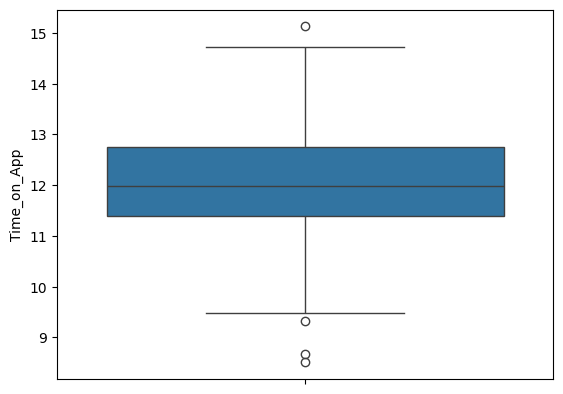

In [149]:

sns.boxplot(df['Time_on_App'])
plt.show()

In [150]:
df_cleaned = df.copy()


(1.3549999999999986, 9.365000000000002, 14.784999999999997)

Time_on_App ([], [])
(1.365000000000002, 34.30499999999999, 39.765)

Time_on_Website ([], [])
(1.1625, 1.2137499999999999, 5.8637500000000005)
214 : 1.14
320 : 1.2

Length_of_Membership ([], [1.14, 1.2])
(102.31499999999994, 292.6125000000001, 701.8725)

Yearly_Amount_Spent ([], [])


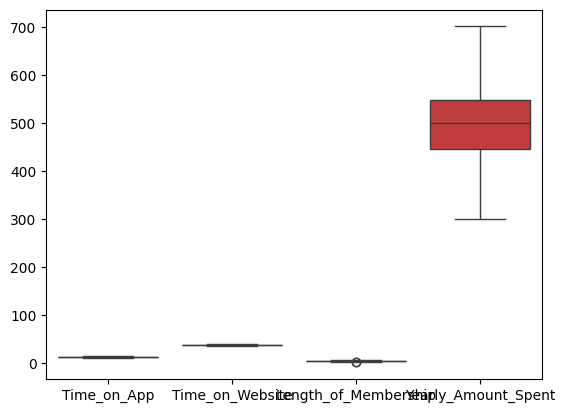

In [151]:
# lets drop outliers
for i in df_cleaned.select_dtypes('number').columns:
    df_cleaned[i] = handler.fit_transform_IQR(df_cleaned[i])

for i in df_cleaned.select_dtypes('number').columns:
    print(handler.fit_IQR(df_cleaned[i]))
    print(f'\n{i:}',handler.display_outliers(df_cleaned[i]))

sns.boxplot(df_cleaned)
plt.show()

In [152]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Time_on_App           496 non-null    float64
 4   Time_on_Website       498 non-null    float64
 5   Length_of_Membership  488 non-null    float64
 6   Yearly_Amount_Spent   491 non-null    float64
dtypes: float64(4), object(3)
memory usage: 27.5+ KB


In [153]:
print(df_cleaned.isna().sum())
df_cleaned.dropna(inplace=True)

Email                    0
Address                  0
Avatar                   0
Time_on_App              4
Time_on_Website          2
Length_of_Membership    12
Yearly_Amount_Spent      9
dtype: int64


### preprocessing
    scale data, dimensionality reduction


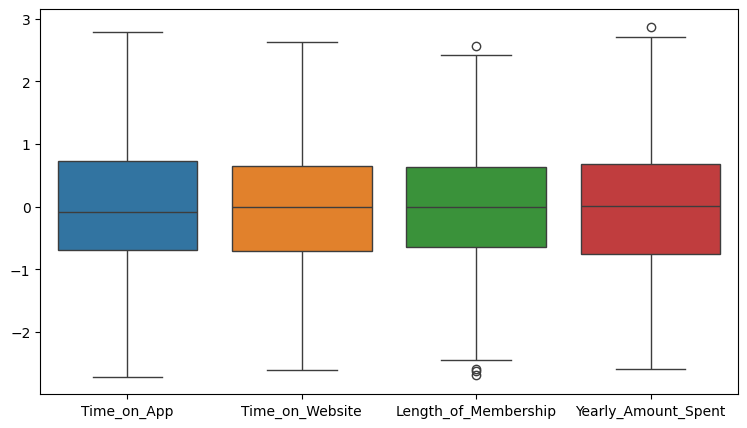

In [154]:
# now its time to scale the data
scaler = StandardScaler()


df_scaled = scaler.fit_transform(df_cleaned.select_dtypes('number'))
df_scaled = pd.DataFrame(df_scaled, columns=df_cleaned.select_dtypes('number').columns)

plt.figure(figsize=(9,5))
sns.boxplot(df_scaled)

plt.show()

In [155]:
df_scaled.isna().sum()

Time_on_App             0
Time_on_Website         0
Length_of_Membership    0
Yearly_Amount_Spent     0
dtype: int64

In [156]:
df_scaled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 479 entries, 0 to 478
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Time_on_App           479 non-null    float64
 1   Time_on_Website       479 non-null    float64
 2   Length_of_Membership  479 non-null    float64
 3   Yearly_Amount_Spent   479 non-null    float64
dtypes: float64(4)
memory usage: 15.1 KB


### lets do the clustering

1916.0000000000002
1336.223495745348
1148.589945458869
975.7997650101566
822.4190761816067
730.6985410562363
672.1859580919544
640.8637691993756
605.4399720292441
570.1161458448341


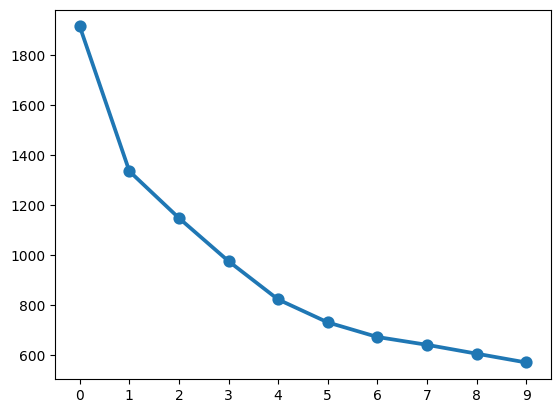

In [157]:
# elbow method
from sklearn.cluster import KMeans 
intertia_list = []
for i in range(1,11):
    k_means = KMeans(n_clusters=i, random_state= 42)
    intertia = k_means.fit(df_scaled).inertia_
    print(intertia)
    intertia_list.append(intertia)
# plt.plot(intertia_list)
sns.pointplot(intertia_list)
plt.show()

## based on the graph above i decided to use 4 clusters

In [158]:
# lets build and train the model 

In [178]:
k_means = KMeans(n_clusters=4, random_state=42) # model building 

clusters = k_means.fit_predict(df_scaled)
df_cleaned['Cluster'] = clusters
df_scaled['Cluster'] = clusters

In [179]:
df_cleaned.head()

,Email,Address,Avatar,Time_on_App,Time_on_Website,Length_of_Membership,Yearly_Amount_Spent,Cluster
0,mstephenson@fernandez.com,"835 Frank TunnelWrightmouth, MI 82180-9605",Violet,12.66,39.58,4.08,587.95,0
1,hduke@hotmail.com,"4547 Archer CommonDiazchester, CA 06566-8576",DarkGreen,11.11,37.27,2.66,392.20,2
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582Cobbborough, DC ...",Bisque,11.33,37.11,4.10,487.55,2
3,riverarebecca@gmail.com,"1414 David ThroughwayPort Jason, OH 22070-1220",SaddleBrown,13.72,36.72,3.12,581.85,0
4,mstephens@davidson-herman.com,"14023 Rodriguez PassagePort Jacobville, PR 372...",MediumAquaMarine,12.80,37.54,4.45,599.41,0


In [180]:
to_plot = df_cleaned.select_dtypes('number').groupby('Cluster').mean()
to_plot = df_scaled.select_dtypes('number').groupby('Cluster').mean()

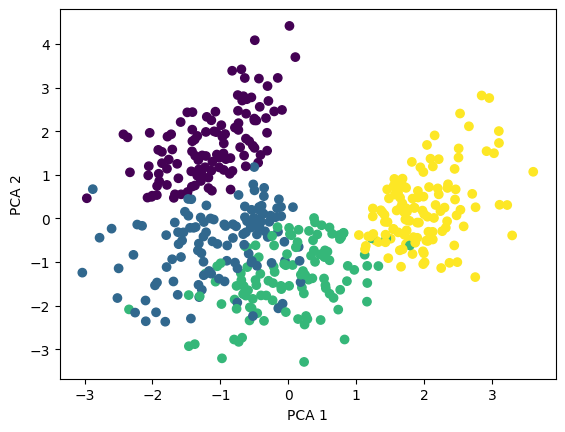

In [189]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

reduced = pca.fit_transform(df_scaled)

plt.scatter(reduced[:,0], reduced[:,1], c=clusters)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

plt.show()

In [186]:
print(df_cleaned.select_dtypes('number').corr())

                      Time_on_App  Time_on_Website  Length_of_Membership  \
Time_on_App              1.000000         0.064248             -0.055434   
Time_on_Website          0.064248         1.000000             -0.045949   
Length_of_Membership    -0.055434        -0.045949              1.000000   
Yearly_Amount_Spent      0.475469        -0.000893              0.763397   
Cluster                 -0.483902        -0.355009              0.354685   

                      Yearly_Amount_Spent   Cluster  
Time_on_App                      0.475469 -0.483902  
Time_on_Website                 -0.000893 -0.355009  
Length_of_Membership             0.763397  0.354685  
Yearly_Amount_Spent              1.000000  0.042920  
Cluster                          0.042920  1.000000  


In [ ]:
print(df_scaled.groupby('Cluster').mean())

,Time_on_App,Time_on_Website,Length_of_Membership,Yearly_Amount_Spent
Cluster,,,,
0,0.924934,0.816762,0.217830,0.697601
1,0.284137,-0.562866,-0.957621,-0.667002
2,-1.052893,0.385992,-0.291372,-0.852867
3,-0.113053,-0.567461,0.990121,0.809563


# Customer Segmentation Analysis

## Cluster Profiles

| Cluster | Time on App | Time on Website | Length of Membership | Yearly Amount Spent | Interpretation |
|---|---|---|---|---|---|
| **0** | High | High | Slightly High | High | Highly engaged multi-platform customers |
| **1** | Slightly High | Low | Very Low | Low | New or low-loyalty mobile-oriented users |
| **2** | Very Low | Slightly High | Low | Very Low | Website browsers / low-value customers |
| **3** | Slightly Low | Low | Very High | Very High | Loyal premium customers |

---

# Detailed Cluster Interpretation

## Cluster 0 — Highly Engaged Multi-Platform Customers

### Characteristics
- High app usage
- High website usage
- Above-average membership duration
- High yearly spending

### Business Interpretation
These customers are highly engaged across both platforms and contribute strong revenue. They actively interact with the business ecosystem and are likely valuable recurring customers.

### Potential Strategies
- Personalized offers
- VIP rewards
- Cross-platform promotions
- Early access programs

---

## Cluster 1 — New Mobile-Oriented Customers

### Characteristics
- Moderate app usage
- Low website usage
- Very low membership duration
- Low yearly spending

### Business Interpretation
These customers are relatively new and primarily engage through the mobile application. They have not yet developed strong loyalty or spending behavior.

### Potential Strategies
- Customer retention campaigns
- Onboarding incentives
- Mobile-exclusive offers
- Loyalty program introduction

---

## Cluster 2 — Website Browsers / Low-Value Customers

### Characteristics
- Very low app usage
- Moderate website usage
- Low membership duration
- Very low yearly spending

### Business Interpretation
These users frequently browse the website but rarely convert into high-value customers. They may represent undecided customers or non-converting traffic.

### Potential Strategies
- Improve website conversion funnels
- Retargeting advertisements
- Personalized product recommendations
- Checkout optimization

---

## Cluster 3 — Loyal Premium Customers

### Characteristics
- Slightly below-average app usage
- Low website usage
- Very high membership duration
- Very high yearly spending

### Business Interpretation
This cluster represents the most valuable customer segment. Despite lower platform activity, these customers maintain strong long-term loyalty and generate the highest revenue.

### Potential Strategies
- Premium membership benefits
- Exclusive rewards
- Long-term loyalty incentives
- Personalized customer relationship management

---

# Key Business Insights

## 1. Customer Loyalty Strongly Influences Spending

The strongest relationship observed in the dataset was between:

- **Length of Membership**
- **Yearly Amount Spent**

This indicates that long-term customers are significantly more likely to spend larger amounts.

---

## 2. Website Activity Alone Does Not Predict Spending

Customers with high website usage were not necessarily high spenders. This suggests that browsing activity alone may not translate directly into purchases.

---

## 3. App Engagement Shows Better Spending Relationship

Users with higher app engagement tended to spend more than users focused mainly on website browsing.

---

# Conclusion

The clustering analysis successfully identified four distinct customer segments with different behavioral and spending patterns.

The results suggest that:
- customer loyalty is the strongest driver of revenue,
- mobile engagement is more valuable than website browsing,
- and customer groups require different marketing and retention strategies.

This segmentation can support:
- targeted marketing,
- personalized recommendations,
- customer retention strategies,
- and revenue optimization.